Projrct Title : Supply Chain Delay Prediction Project Guide


Problem Statement


Logistics and supply chain companies need to predict shipment delays to optimize operations and improve
customer satisfaction. The objective of this project is to predict the delay duration (in hours) using shipment,
route, warehouse, and external factors.

Data Dictionary


distance_km, shipment_weight, shipment_volume, traffic_index, route_complexity_score, number_of_stops,
driver_experience_years, origin_warehouse_load, destination_warehouse_load, processing_time_hours,
fuel_price, holiday_flag, strike_flag, dispatch_delay_hours, handling_issues_count, documentation_delay_flag,
delay_duration_hours (target)

EDA Questions


1. What is the distribution of delay_duration_hours?
2. How does distance_km affect delay?
3. Does traffic_index increase delay significantly?
4. How does route_complexity_score impact delay?
5. Do more stops increase delay?
6. Does driver experience reduce delay?
7. How does warehouse load affect delays?
8. Do holidays increase delays?
9. Do strikes cause extreme delays?
10. How does weather impact delay?
11. Which transport mode causes highest delay?
12. Is delay higher for long distance shipments?
13. Are there outliers in delay?
14. Which features are most correlated with delay?
15. Does dispatch delay directly affect final delay?
16. Are there nonlinear relationships present?
17. Do combinations of traffic + weather increase delay?
18. Does fuel price impact indirectly?
19. Which factor contributes most to delay?
20. What patterns can be observed overall?


Feature Engineering


Create new features such as: • delay_per_km
• load_ratio
• traffic_category
• risk_score
• weather_severity_index

Feature Scaling


Apply scaling for KNN and Polynomial Regression using StandardScaler or MinMaxScaler

Model Building


Train: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost,
KNN.
Model Evaluation
Use MAE, MSE, RMSE, and R² Score to compare models

Model Building


Train: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost,
KNN.
Model Evaluation
Use MAE, MSE, RMSE, and R² Score to compare models

In [9]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
df=pd.read_csv("Downloads/supply_chain_delay_dataset.csv")

In [5]:
df.head()

,product_category,transport_mode,weather_condition,distance_km,shipment_weight,shipment_volume,traffic_index,route_complexity_score,number_of_stops,driver_experience_years,origin_warehouse_load,destination_warehouse_load,processing_time_hours,fuel_price,holiday_flag,strike_flag,dispatch_delay_hours,handling_issues_count,documentation_delay_flag,delay_duration_hours
0,Pharma,Road,Rain,176.63,321.90,1.46,5.66,5.91,9,13.14,0.42,1.03,8.24,117.22,0,0,15.41,1,0,78.67
1,Food,Road,Rain,2239.78,202.94,0.78,6.58,5.79,3,6.07,0.41,0.84,47.42,112.35,0,0,13.90,2,0,98.90
2,Furniture,Air,Rain,2645.33,17.03,1.40,8.25,3.66,8,2.76,0.64,0.60,2.35,107.45,0,0,20.30,1,0,118.24
3,Food,Air,Clear,1304.49,325.82,4.30,4.05,1.05,5,9.05,0.59,1.08,2.48,75.23,0,0,17.94,1,0,64.03
4,Food,Road,Rain,1270.16,196.31,3.17,7.05,7.70,3,4.03,0.46,1.16,5.94,109.73,0,0,8.85,0,0,86.09


In [6]:
df.tail()

,product_category,transport_mode,weather_condition,distance_km,shipment_weight,shipment_volume,traffic_index,route_complexity_score,number_of_stops,driver_experience_years,origin_warehouse_load,destination_warehouse_load,processing_time_hours,fuel_price,holiday_flag,strike_flag,dispatch_delay_hours,handling_issues_count,documentation_delay_flag,delay_duration_hours
9995,Clothing,Road,Clear,1624.48,327.78,0.81,6.46,7.57,1,19.58,1.42,0.84,20.06,103.64,1,0,3.31,3,0,76.56
9996,Clothing,Road,Fog,1802.60,363.49,5.00,9.09,9.30,4,2.20,1.25,1.30,39.21,78.59,0,0,3.84,4,0,136.07
9997,Clothing,Sea,Rain,2534.51,416.89,3.29,5.74,5.52,5,12.90,0.55,0.56,8.72,91.72,0,0,19.45,2,0,107.35
9998,Clothing,Sea,Clear,199.41,56.28,4.02,8.37,1.93,5,0.95,1.23,1.34,1.72,105.90,0,0,14.26,0,0,90.10
9999,Pharma,Air,Rain,1191.97,381.17,2.00,2.94,6.26,0,10.58,0.70,0.47,35.91,90.96,1,0,16.91,4,1,80.86


In [7]:
df.isnull().sum()

product_category              0
transport_mode                0
weather_condition             0
distance_km                   0
shipment_weight               0
shipment_volume               0
traffic_index                 0
route_complexity_score        0
number_of_stops               0
driver_experience_years       0
origin_warehouse_load         0
destination_warehouse_load    0
processing_time_hours         0
fuel_price                    0
holiday_flag                  0
strike_flag                   0
dispatch_delay_hours          0
handling_issues_count         0
documentation_delay_flag      0
delay_duration_hours          0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_category            10000 non-null  object 
 1   transport_mode              10000 non-null  object 
 2   weather_condition           10000 non-null  object 
 3   distance_km                 10000 non-null  float64
 4   shipment_weight             10000 non-null  float64
 5   shipment_volume             10000 non-null  float64
 6   traffic_index               10000 non-null  float64
 7   route_complexity_score      10000 non-null  float64
 8   number_of_stops             10000 non-null  int64  
 9   driver_experience_years     10000 non-null  float64
 10  origin_warehouse_load       10000 non-null  float64
 11  destination_warehouse_load  10000 non-null  float64
 12  processing_time_hours       10000 non-null  float64
 13  fuel_price                  1000

In [9]:
df.describe()

,distance_km,shipment_weight,shipment_volume,traffic_index,route_complexity_score,number_of_stops,driver_experience_years,origin_warehouse_load,destination_warehouse_load,processing_time_hours,fuel_price,holiday_flag,strike_flag,dispatch_delay_hours,handling_issues_count,documentation_delay_flag,delay_duration_hours
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1526.522569,251.119587,2.568797,5.550991,5.467110,4.538000,10.227778,0.902699,0.898996,24.451236,94.869113,0.14770,0.047200,12.103856,1.508400,0.100300,91.083836
std,849.725494,144.405285,1.408730,2.614869,2.611094,2.868271,5.595372,0.347071,0.346429,13.591480,14.427318,0.35482,0.212077,6.935224,1.227713,0.300415,19.645111
min,50.060000,1.050000,0.100000,1.000000,1.000000,0.000000,0.510000,0.300000,0.300000,1.010000,70.000000,0.00000,0.000000,0.000000,0.000000,0.000000,29.350000
25%,802.110000,126.317500,1.360000,3.300000,3.210000,2.000000,5.340000,0.600000,0.600000,12.557500,82.407500,0.00000,0.000000,6.040000,1.000000,0.000000,77.447500
50%,1535.040000,250.455000,2.570000,5.530000,5.425000,5.000000,10.240000,0.910000,0.900000,24.460000,94.715000,0.00000,0.000000,12.160000,1.000000,0.000000,90.735000
75%,2261.767500,376.975000,3.800000,7.860000,7.732500,7.000000,15.030000,1.200000,1.200000,36.290000,107.162500,0.00000,0.000000,18.102500,2.000000,0.000000,104.532500
max,2999.920000,499.900000,5.000000,10.000000,10.000000,9.000000,20.000000,1.500000,1.500000,47.990000,120.000000,1.00000,1.000000,24.000000,8.000000,1.000000,158.140000


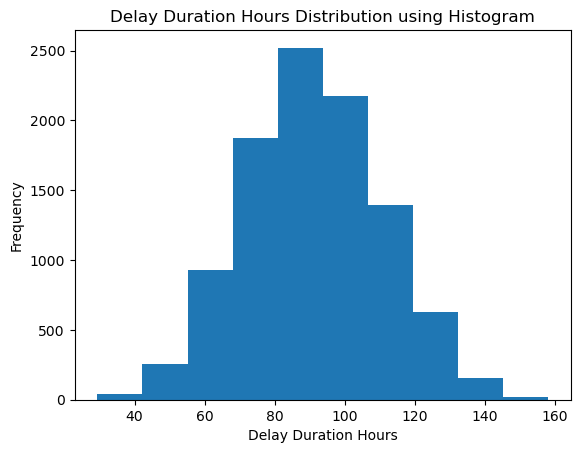

In [10]:
plt.hist(df["delay_duration_hours"])
plt.title("Delay Duration Hours Distribution using Histogram")
plt.xlabel("Delay Duration Hours")
plt.ylabel("Frequency")
plt.show()


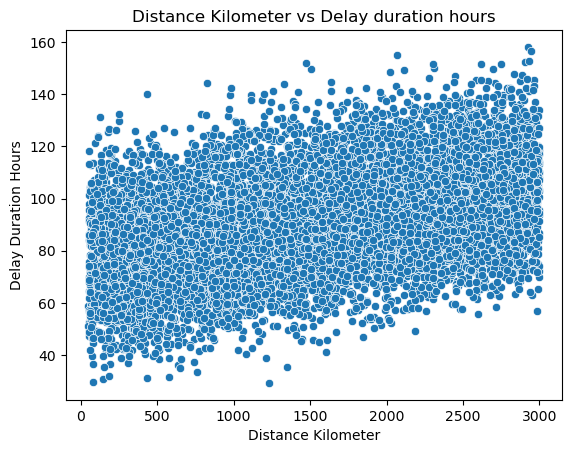

In [11]:
sns.scatterplot(x='distance_km', y='delay_duration_hours', data=df)
plt.title("Distance km Distribution Delay duration hours")
plt.xlabel("Distance Kilometer")
plt.ylabel("Delay Duration Hours")
plt.show()

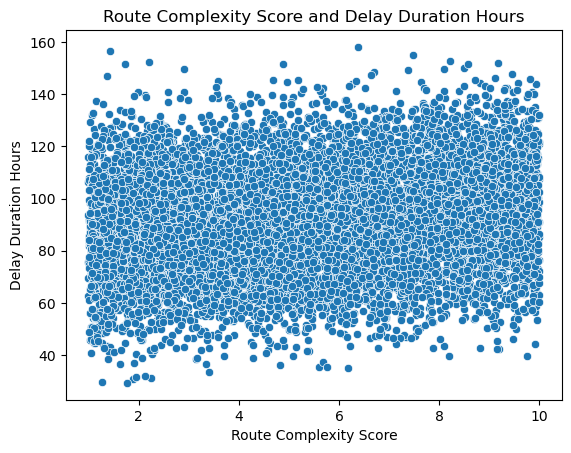

In [16]:
sns.scatterplot(x='route_complexity_score', y='delay_duration_hours', data=df)
plt.title("Route Complexity Score and Delay Duration Hours")
plt.xlabel("Route Complexity Score")
plt.ylabel("Delay Duration Hours")
plt.show()

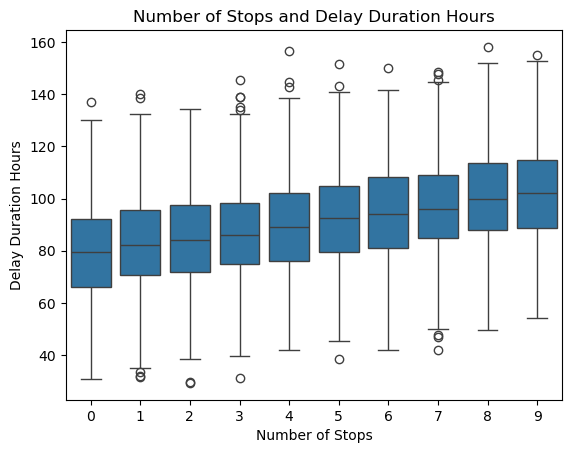

In [17]:
sns.boxplot(x='number_of_stops', y='delay_duration_hours', data=df)
plt.title('Number of Stops vs Delay Duration Hours')
plt.xlabel('Number of Stops')
plt.ylabel('Delay Duration Hours')
plt.show()

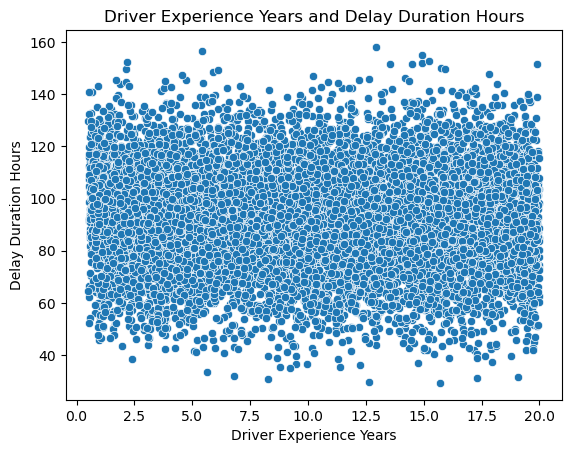

In [18]:
sns.scatterplot(x='driver_experience_years', y='delay_duration_hours', data=df)
plt.title("Driver Experience Years vs Delay Duration Hours")
plt.xlabel("Driver Experience Years")
plt.ylabel("Delay Duration Hours")
plt.show()


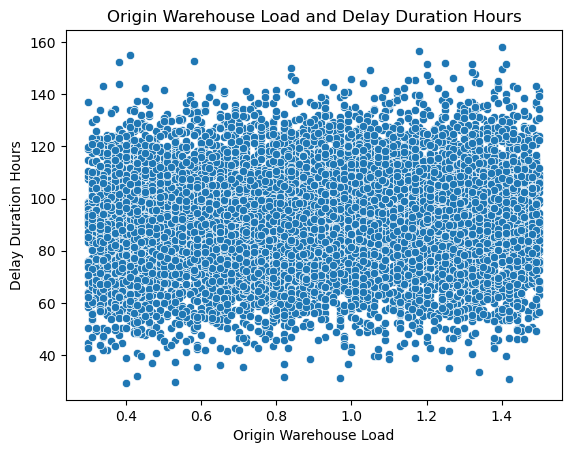

In [19]:
sns.scatterplot(x='origin_warehouse_load', y='delay_duration_hours', data=df)
plt.title("Origin Warehouse Load vs Delay Duration Hours")
plt.xlabel("Origin Warehouse Load")
plt.ylabel("Delay Duration Hours")
plt.show()

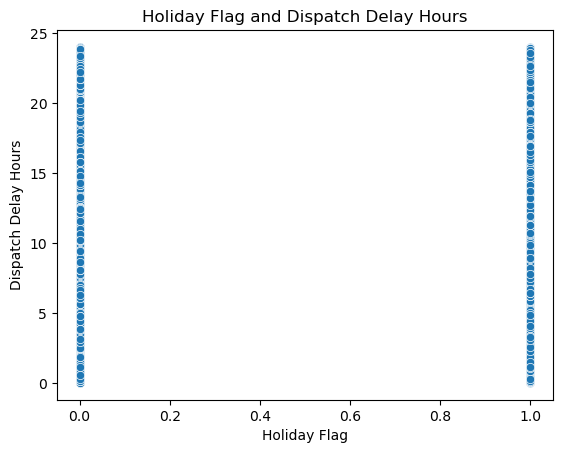

In [20]:
sns.scatterplot(x='holiday_flag', y='dispatch_delay_hours', data=df)
plt.title("Holiday Flag and Dispatch Delay Hours")
plt.xlabel("Holiday Flag")
plt.ylabel("Dispatch Delay Hours")
plt.show()

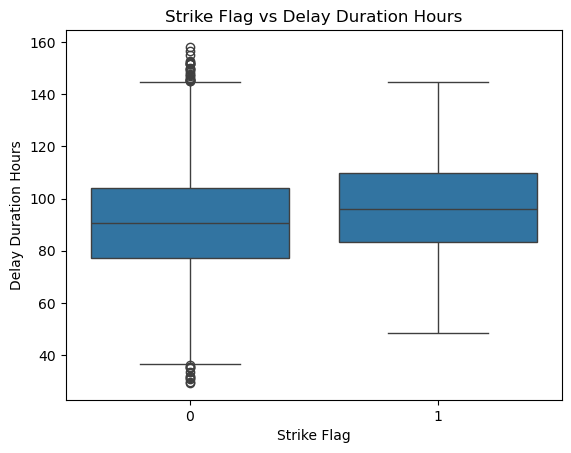

In [4]:
sns.boxplot(x="strike_flag",y="delay_duration_hours",data=df)
plt.title('Strike Flag vs Delay Duration Hours')
plt.xlabel('Strike Flag')
plt.ylabel('Delay Duration Hours')
plt.show()


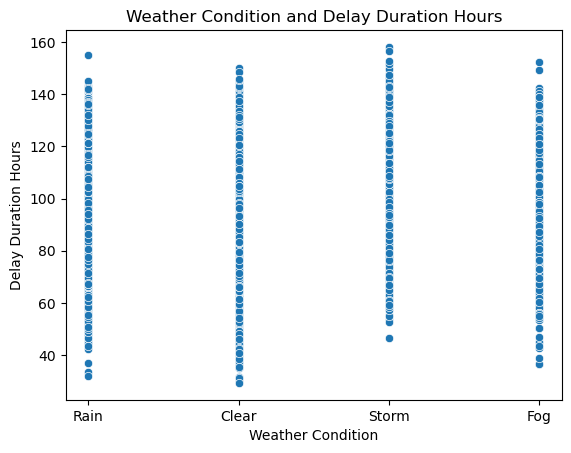

In [22]:
sns.scatterplot(x='weather_condition', y='delay_duration_hours', data=df)
plt.title('Weather Condition and Delay Duration Hours')
plt.xlabel('Weather Condition')
plt.ylabel('Delay Duration Hours')
plt.show()

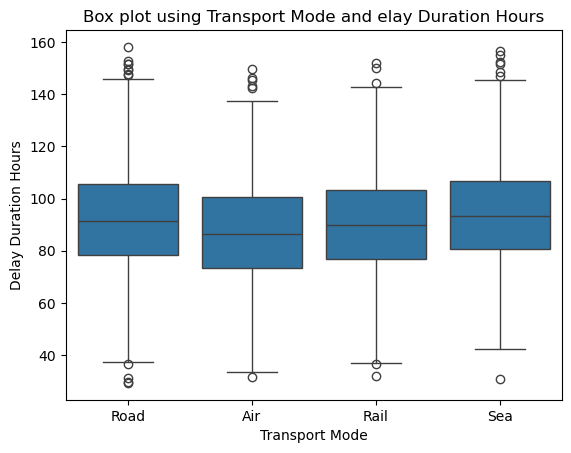

In [23]:
sns.boxplot(x='transport_mode', y='delay_duration_hours', data=df)
plt.title("Box plot using Transport Mode and elay Duration Hours")
plt.xlabel('Transport Mode')
plt.ylabel('Delay Duration Hours')
plt.show()


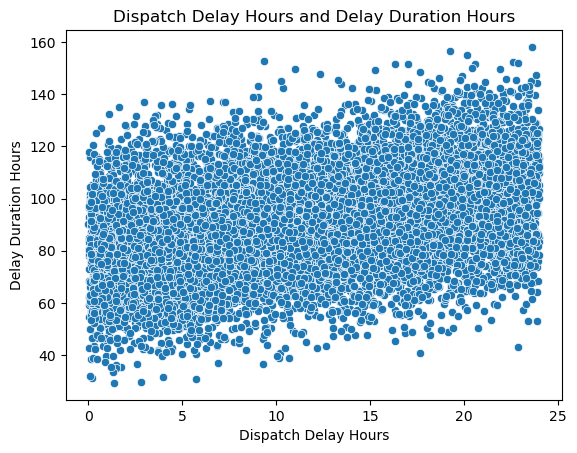

In [24]:
sns.scatterplot(x='dispatch_delay_hours', y='delay_duration_hours', data=df)
plt.title('Dispatch Delay Hours and Delay Duration Hours')
plt.xlabel('Dispatch Delay Hours')
plt.ylabel('Delay Duration Hours')
plt.show()

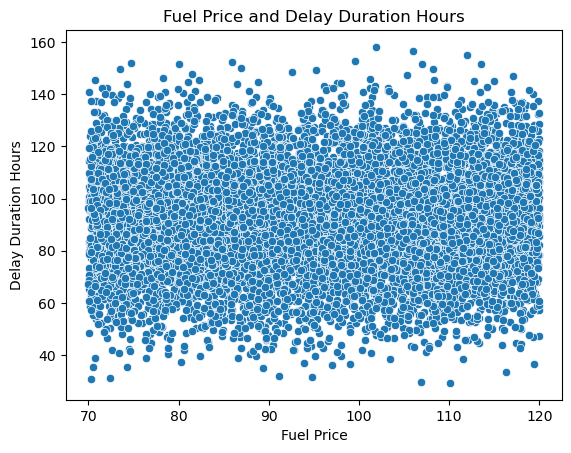

In [25]:
sns.scatterplot(x='fuel_price', y='delay_duration_hours', data=df)
plt.title('Fuel Price and Delay Duration Hours')
plt.xlabel('Fuel Price')
plt.ylabel('Delay Duration Hours')
plt.show()

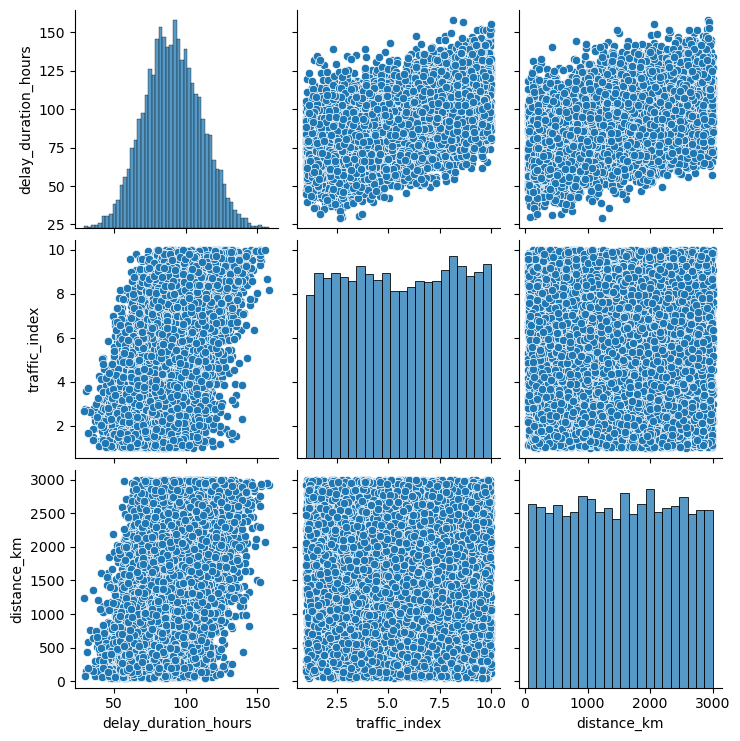

In [26]:
sns.pairplot(df[['delay_duration_hours','traffic_index','distance_km']])
plt.show()

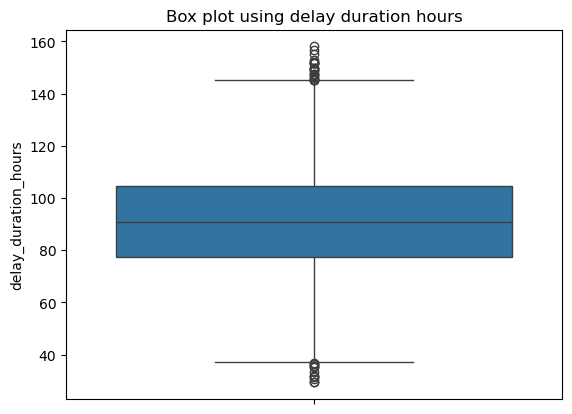

In [6]:
sns.boxplot(df['delay_duration_hours'])
plt.title('Box plot using delay duration hours')
plt.show()


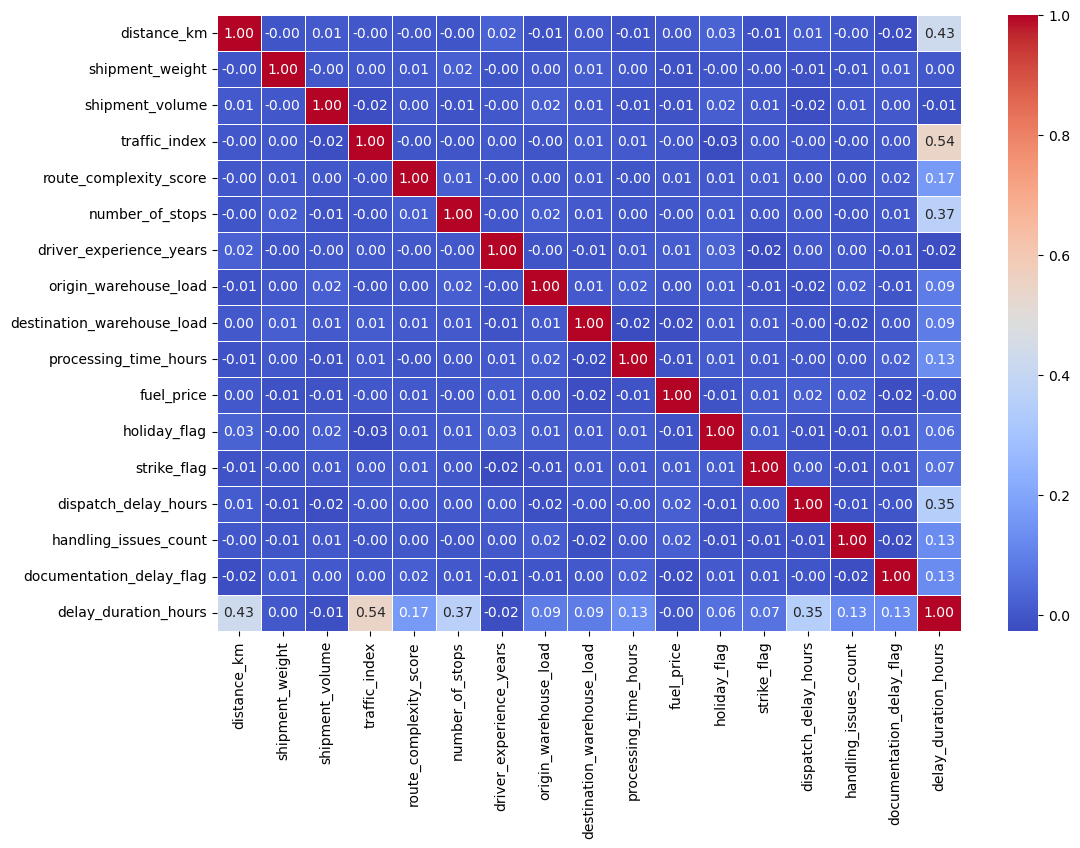

In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True,fmt=".2f", cmap='coolwarm',linewidths=0.5)
plt.show()


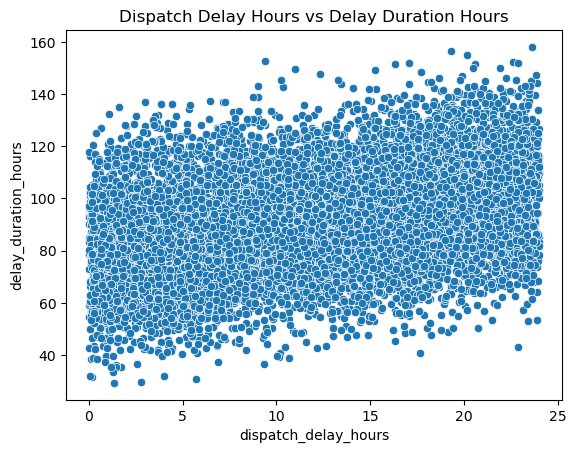

In [8]:
sns.scatterplot(x='dispatch_delay_hours', y='delay_duration_hours', data=df)
plt.title('Dispatch Delay Hours vs Delay Duration Hours')
plt.show()

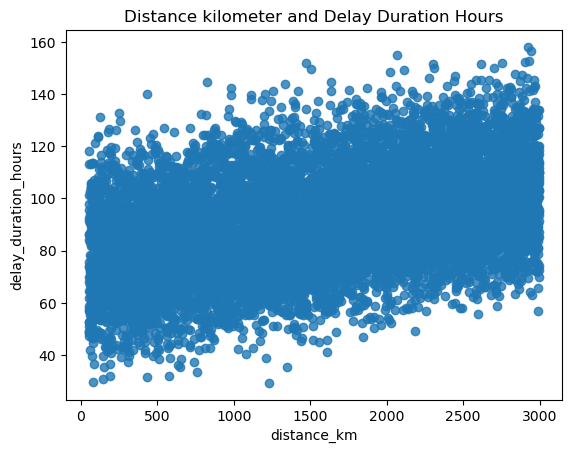

In [9]:
sns.regplot(x='distance_km', y='delay_duration_hours', data=df)
plt.title('Distance kilometer and Delay Duration Hours')
plt.show()

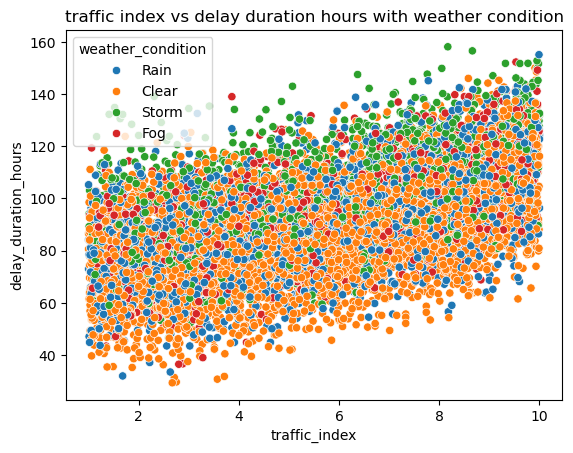

In [10]:
sns.scatterplot(x='traffic_index',y='delay_duration_hours',hue='weather_condition',data=df)
plt.title('traffic index vs delay duration hours with weather condition')
plt.show()

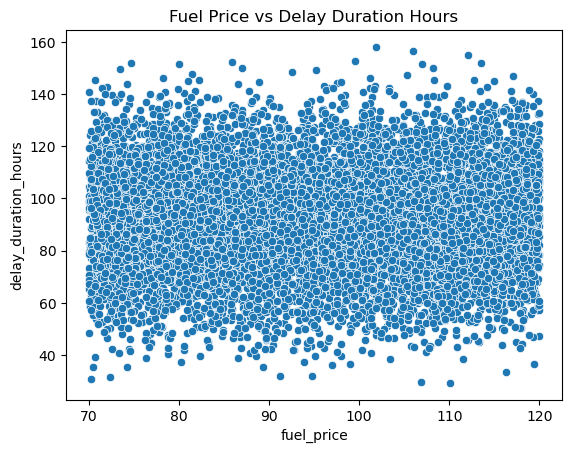

In [11]:
sns.scatterplot(x='fuel_price', y='delay_duration_hours', data=df)
plt.title('Fuel Price vs Delay Duration Hours')
plt.show()

In [6]:
corr['delay_duration_hours'].sort_values(ascending=False)

delay_duration_hours          1.000000
traffic_index                 0.543387
distance_km                   0.429747
number_of_stops               0.365419
dispatch_delay_hours          0.353908
route_complexity_score        0.167224
processing_time_hours         0.133715
handling_issues_count         0.129305
documentation_delay_flag      0.126197
destination_warehouse_load    0.089316
origin_warehouse_load         0.088724
strike_flag                   0.067180
holiday_flag                  0.059003
shipment_weight               0.004508
fuel_price                   -0.000199
shipment_volume              -0.014787
driver_experience_years      -0.020945
Name: delay_duration_hours, dtype: float64

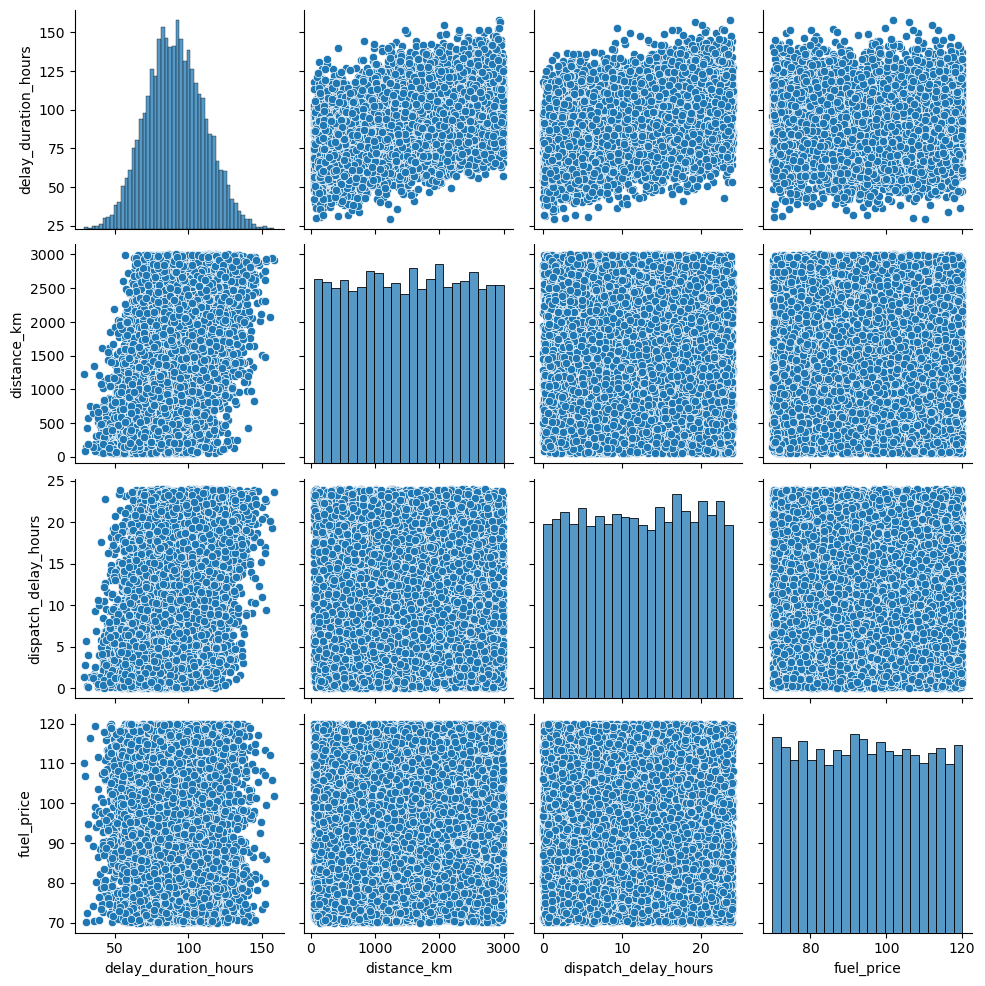

In [7]:
sns.pairplot(df[['delay_duration_hours', 'distance_km', 'dispatch_delay_hours', 'fuel_price']])
plt.show()

In [8]:
df.head()

,product_category,transport_mode,weather_condition,distance_km,shipment_weight,shipment_volume,traffic_index,route_complexity_score,number_of_stops,driver_experience_years,origin_warehouse_load,destination_warehouse_load,processing_time_hours,fuel_price,holiday_flag,strike_flag,dispatch_delay_hours,handling_issues_count,documentation_delay_flag,delay_duration_hours
0,Pharma,Road,Rain,176.63,321.90,1.46,5.66,5.91,9,13.14,0.42,1.03,8.24,117.22,0,0,15.41,1,0,78.67
1,Food,Road,Rain,2239.78,202.94,0.78,6.58,5.79,3,6.07,0.41,0.84,47.42,112.35,0,0,13.90,2,0,98.90
2,Furniture,Air,Rain,2645.33,17.03,1.40,8.25,3.66,8,2.76,0.64,0.60,2.35,107.45,0,0,20.30,1,0,118.24
3,Food,Air,Clear,1304.49,325.82,4.30,4.05,1.05,5,9.05,0.59,1.08,2.48,75.23,0,0,17.94,1,0,64.03
4,Food,Road,Rain,1270.16,196.31,3.17,7.05,7.70,3,4.03,0.46,1.16,5.94,109.73,0,0,8.85,0,0,86.09


In [10]:
df.columns

Index(['product_category', 'transport_mode', 'weather_condition',
       'distance_km', 'shipment_weight', 'shipment_volume', 'traffic_index',
       'route_complexity_score', 'number_of_stops', 'driver_experience_years',
       'origin_warehouse_load', 'destination_warehouse_load',
       'processing_time_hours', 'fuel_price', 'holiday_flag', 'strike_flag',
       'dispatch_delay_hours', 'handling_issues_count',
       'documentation_delay_flag', 'delay_duration_hours'],
      dtype='object')

Feature Engineering

Create new features such as: • delay_per_km • load_ratio • traffic_category • risk_score • weather_severity_index

In [12]:
df['delay_per_km'] = df['delay_duration_hours'] / df['distance_km']

In [13]:
df['load_ratio'] = df['origin_warehouse_load'] / (df['destination_warehouse_load'] + 1)

In [14]:
df['traffic_category'] = pd.cut(df['traffic_index'], bins=3)

In [15]:
df['risk_score'] = (
    df['strike_flag'] +
    df['holiday_flag'] +
    df['handling_issues_count']
)

In [16]:
df['weather_severity'] = df['weather_condition'].map({'Clear': 1,'Cloudy': 2,'Rain': 3,'Storm': 5})

In [11]:
X = df.drop('delay_duration_hours', axis=1)
y = df['delay_duration_hours']

In [16]:
X = pd.get_dummies(X, columns=[
    'product_category',
    'transport_mode',
    'weather_condition'
], drop_first=True)

In [17]:
X = pd.get_dummies(X, drop_first=True)

In [18]:
X = X.fillna(X.mean())

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
print(X_train.dtypes)

distance_km                     float64
shipment_weight                 float64
shipment_volume                 float64
traffic_index                   float64
route_complexity_score          float64
number_of_stops                   int64
driver_experience_years         float64
origin_warehouse_load           float64
destination_warehouse_load      float64
processing_time_hours           float64
fuel_price                      float64
holiday_flag                      int64
strike_flag                       int64
dispatch_delay_hours            float64
handling_issues_count             int64
documentation_delay_flag          int64
product_category_Clothing          bool
product_category_Electronics       bool
product_category_Food              bool
product_category_Furniture         bool
product_category_Pharma            bool
transport_mode_Rail                bool
transport_mode_Road                bool
transport_mode_Sea                 bool
weather_condition_Fog              bool


Feature Scaling

Apply scaling for KNN and Polynomial Regression using StandardScaler or MinMaxScaler.

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Model Building

Train: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, KNN.
Model Evaluation Use MAE, MSE, RMSE, and R² Score to compare models.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 4.3615074187320895
RMSE: 5.459454577273498
R2 Score: 0.9277679407700857


In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)
print("\nPolynomial Regression")
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)


Polynomial Regression
MAE: 4.152265930314988
RMSE: 5.190019157354269
R2 Score: 0.9347216146085684


In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
print("\nDecision Tree")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)


Decision Tree
MAE: 10.01982
RMSE: 12.597659056348524
R2 Score: 0.6153983147207774


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("\nRandom Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)


Random Forest
MAE: 6.946375399999999
RMSE: 8.697353335841312
R2 Score: 0.8166817469242963


In [37]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print("\nGradient Boosting")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)


Gradient Boosting
MAE: 5.501052300484536
RMSE: 6.886919742323809
R2 Score: 0.8850572652099119


In [40]:
pip install xgboost

In [41]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
print("\nKNN")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)


KNN
MAE: 10.790822
RMSE: 13.450829274212055
R2 Score: 0.5615403802005177
